# 07 - Compare Results

**Where this fits:** this is the final notebook — the payoff for everything
that came before it. Three independent approaches to the same question ("how
should 50,000 naloxone kits be distributed across Rhode Island?") converge
here:

- **Status quo** (`00_status_quo_distribution.ipynb`) — what Rhode Island
  currently does, used as the baseline.
- **Greedy benchmark** (`06_greedy_benchmark.ipynb`) — a simpler, classical
  approach, treating each city independently.
- **Metamodel optimization** (`01`–`05`) — a neural network surrogate for the
  real microsimulation, optimized over the full 39-dimensional allocation
  space and validated against ground-truth simulation results.

Each approach's results were saved to `results/outputs/` by its respective
notebook; this notebook just reads those three files back in and compares
them side by side. The three-approach structure itself is a deliberate check
on the neural network result — if the sophisticated metamodel approach didn't
at least match the much simpler greedy approach, that would be a red flag that
something was wrong with the metamodel rather than evidence that the greedy
method was better.

In this notebook, the results from the status quo (`00_status_quo_distribution.ipynb`),
greedy algorithm (`06_greedy_benchmark.ipynb`), and metamodel optimization
(`05_find_optimal_solutions.ipynb`) approaches are all compared.</cell id="6adea86d-13b2-4519-abb4-681c893ba7ea">

In [1]:
from pathlib import Path

# Repo root (1 level up from notebooks/)
BASE_DIR = Path.cwd().parents[0]
output_dir = BASE_DIR / "results" / "outputs"

# Build file paths
file_path_1 = output_dir / "status_quo_results.csv"
file_path_2 = output_dir / "greedy_algo_results.csv"
file_path_3 = output_dir / "metamodel_results.csv"

In [2]:
import pandas as pd

status_quo_results = pd.read_csv(file_path_1, index_col=0)
status_quo_results

,od_death_2026,Barrington,Bristol,Burrillville,Central.Falls,Charlestown,Coventry,Cranston,Cumberland,East.Greenwich,...,Scituate,Smithfield,South.Kingstown,Tiverton,Warren,Warwick,West.Greenwich,West.Warwick,Westerly,Woonsocket
0,362.93,290,251,221,276,816,131,3077,115,155,...,104,453,4271,538,2420,3760,64,1855,1219,4134


In [3]:
greedy_algo_results = pd.read_csv(file_path_2, index_col=0)
greedy_algo_results

,od_death_2026,Barrington,Bristol,Burrillville,Central.Falls,Charlestown,Coventry,Cranston,Cumberland,East.Greenwich,...,Scituate,Smithfield,South.Kingstown,Tiverton,Warren,Warwick,West.Greenwich,West.Warwick,Westerly,Woonsocket
0,342.79,807,1606,759,1157,46,1911,4273,2144,584,...,274,1449,1032,758,67,3710,392,1356,802,1347


In [4]:
metamodel_results = pd.read_csv(file_path_3, index_col=0)
metamodel_results = metamodel_results.reset_index(drop=True)
metamodel_results

,od_death_2026,Barrington,Bristol,Burrillville,Central.Falls,Charlestown,Coventry,Cranston,Cumberland,East.Greenwich,...,Scituate,Smithfield,South.Kingstown,Tiverton,Warren,Warwick,West.Greenwich,West.Warwick,Westerly,Woonsocket
0,342.26,633.676682,1184.737066,856.002023,997.837039,521.094141,1408.820024,3933.202584,2082.904625,479.956151,...,558.366683,1177.208583,1543.773024,709.628788,489.744133,3813.905977,224.635991,1626.639884,904.654289,1790.007264
1,342.52,627.614943,1171.524605,901.090617,1036.579061,596.042656,1452.078650,3993.264228,2214.805094,419.035833,...,572.822535,1146.916490,1670.404258,624.007704,272.027875,3712.601106,256.032434,1681.053192,964.204376,1873.951480
2,342.55,628.700250,1137.749536,899.606233,1063.170335,564.672374,1303.049173,4173.362138,2162.725263,379.013905,...,537.150114,1122.379274,1478.459224,648.252680,360.045191,3774.229794,270.622491,1697.653946,945.096040,1909.248983
3,342.57,627.652872,1181.997946,930.532242,1003.056517,476.268467,1498.544071,3849.960983,2157.101481,480.659420,...,498.719590,1194.294831,1612.640851,622.010894,357.491871,3893.515523,230.409862,1691.800249,857.935906,1777.306217
4,342.59,660.246173,1170.696943,826.441907,957.187773,401.328763,1271.873940,4099.837645,2211.344908,461.371480,...,524.800632,1178.492514,1591.819069,654.376263,362.778119,3586.389418,200.961959,1664.441398,886.101957,1910.169876
5,342.68,579.166946,1143.805523,877.368500,1013.562876,537.381968,1402.550669,3963.367718,2219.143817,432.789880,...,532.967796,1111.955034,1650.033853,646.692283,399.063982,3946.866937,238.032182,1631.790138,893.439787,1840.911363
6,342.71,609.029277,1126.405964,899.029110,1065.325369,584.644565,1359.021054,4071.445738,2137.412656,380.003648,...,546.969425,1082.417339,1493.690307,646.756722,381.508141,3986.902796,270.495588,1673.163423,939.764239,1869.320023
7,342.83,590.116465,1141.774068,909.948410,1020.598194,536.326379,1400.661797,4001.950368,2192.234516,436.101051,...,532.608017,1112.821444,1617.129044,631.338352,391.985523,3905.645647,247.120276,1655.081876,900.368395,1864.344304
8,342.88,624.104173,1157.827309,881.842083,1055.252236,538.856279,1371.532438,4010.734103,2183.576468,347.860494,...,522.605914,1170.283785,1373.270470,646.233704,347.131171,3829.665212,221.102574,1674.477026,918.660609,1825.894722
9,342.88,631.147375,1141.939077,905.750470,1076.725403,560.005392,1315.482814,4133.991535,2130.913003,364.908979,...,534.232203,1115.939635,1471.181047,645.490971,359.644389,3870.260315,274.827069,1695.957261,943.365212,1875.253489


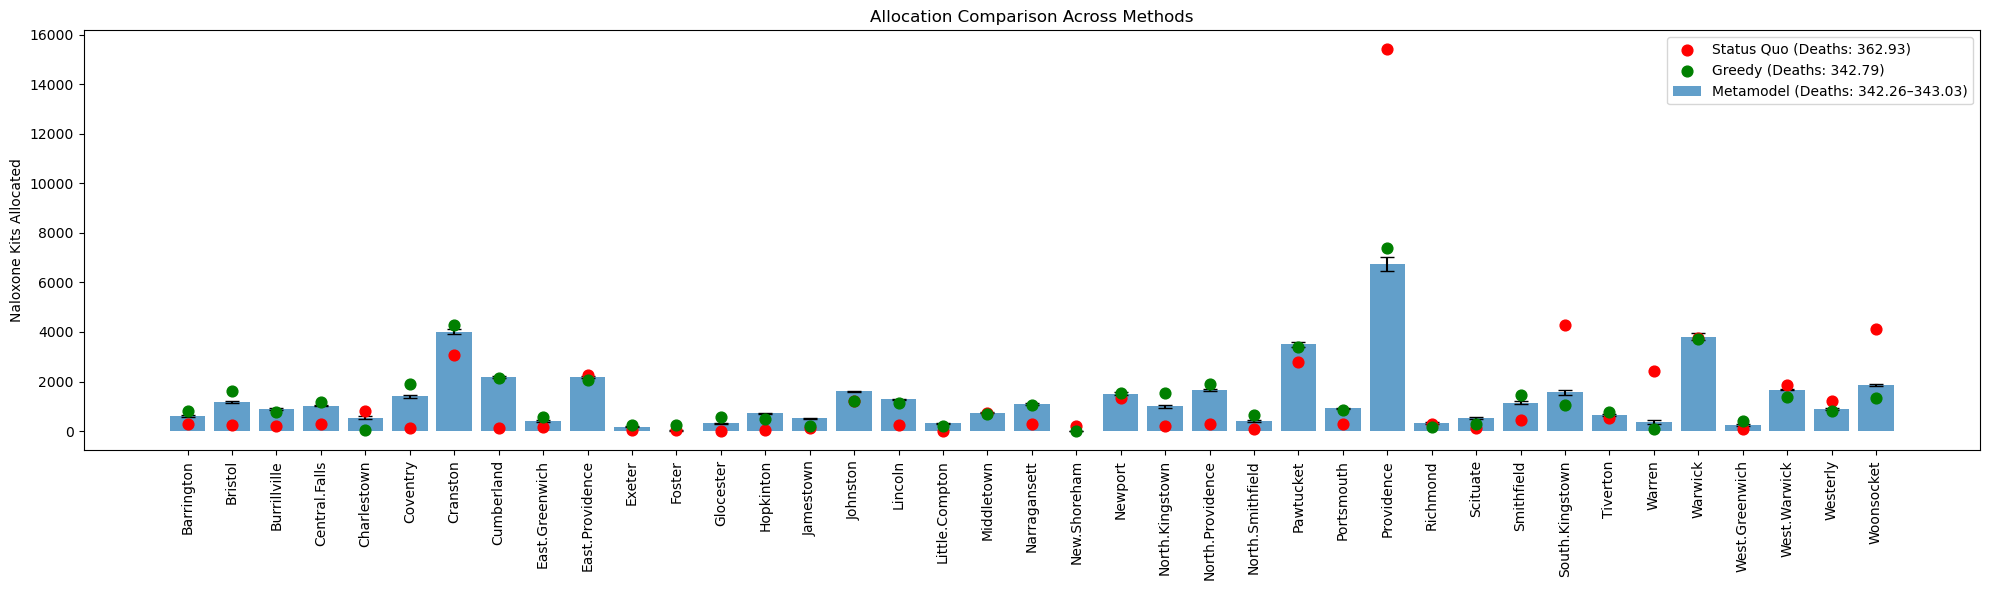

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Metamodel stats
stats_df = metamodel_results.iloc[:, 1:]
means = stats_df.mean()
stds = stats_df.std()

# Status quo + greedy
status_quo_values = status_quo_results.iloc[0, 1:]
greedy_values = greedy_algo_results.iloc[0, 1:]

# Death values
sq_deaths = status_quo_results.iloc[0, 0]
greedy_deaths = greedy_algo_results.iloc[0, 0]

meta_deaths = metamodel_results.iloc[:, 0]
meta_min = meta_deaths.min()
meta_max = meta_deaths.max()

# Plot
plt.figure(figsize=(20, 6))

# Metamodel bars
plt.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=5,
    alpha=0.7,
    label=f'Metamodel (Deaths: {meta_min:.2f}–{meta_max:.2f})'
)

# Status quo points
plt.scatter(
    means.index,
    status_quo_values.values,
    color='red',
    zorder=3,
    s=60,
    label=f'Status Quo (Deaths: {sq_deaths:.2f})'
)

# Greedy points
plt.scatter(
    means.index,
    greedy_values.values,
    color='green',
    zorder=3,
    s=60,
    label=f'Greedy (Deaths: {greedy_deaths:.2f})'
)

# Formatting
plt.xticks(rotation=90)
plt.ylabel('Naloxone Kits Allocated')
plt.title('Allocation Comparison Across Methods')
plt.legend()
plt.tight_layout()
plt.show()

## Takeaway

Reading the plot above: the red dot (status quo) sits noticeably higher than
both the green dot (greedy) and the blue bars (metamodel) in projected deaths
— meaning both alternative approaches genuinely outperform what Rhode Island
currently does. The greedy and metamodel approaches land within a fraction of
a percent of each other (342.79 vs. 342.26–343.03 deaths), despite being
built on completely different methods — one a simple, provably-optimal
per-city curve fit, the other a neural network searching the full joint
allocation space. That agreement is reassuring: it suggests both approaches
are converging on a real, similar answer rather than exploiting a quirk in
one particular method. The metamodel's real advantage over the greedy
approach isn't a lower death count here — it's that it doesn't rely on
treating cities as independent, so it generalizes to problems where that
assumption doesn't hold.